# Masking and reducing data-cubes using geometry objects

In [1]:
# If first time running, uncomment the line below to install any additional dependancies
# !bash requirements-for-notebooks.sh

In [20]:
import matplotlib.pyplot as plt

import earthkit.transforms as ek_aggregate
from earthkit import data as ek_data

from earthkit.data.testing import earthkit_remote_test_data_file

## Load some test data

All `earthkit-climate` methods can be called with `earthkit-data` objects (Readers and Wrappers) or with the 
pre-loaded `xarray` or `geopandas` objects.

In this example we will use hourly ERA5 2m temperature data on a 0.5x0.5 spatial grid for the year 2015 as
our physical data; and we will use the NUTS geometries which are stored in a geojson file.

First we lazily load the ERA5 data  and NUTS geometries from our test-data repository.

Note the data is only downloaded when
we use it, e.g. at the `.to_xarray` line, additionally, the download is cached so the next time you run this
cell you will not need to re-download the file (unless it has been a very long time since you have run the
code, please see tutorials in `earthkit-data` for more details in cache management).

In [15]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
remote_era5_file = earthkit_remote_test_data_file("era5_temperature_europe_2015.grib")
era5_data = ek_data.from_source("url", remote_era5_file)
era5_data.to_xarray()

<xarray.Dataset> Size: 660MB
Dimensions:                  (forecast_reference_time: 1460, latitude: 201,
                              longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 660MB ...
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

In [16]:
# Use some demonstration polygons stored, this could be any url or path to geojson file
remote_nuts_url = earthkit_remote_test_data_file("NUTS_RG_60M_2021_4326_LEVL_0.geojson")
nuts_data = ek_data.from_source("url", remote_nuts_url)

nuts_data.to_pandas()[:5]

,id,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,DK,DK,0,DK,Danmark,Danmark,0,0,0,DK,"MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996..."
1,RS,RS,0,RS,Serbia,Srbija/Сpбија,0,0,0,RS,"POLYGON ((21.4792 45.193, 21.3585 44.8216, 22...."
2,EE,EE,0,EE,Eesti,Eesti,0,0,0,EE,"MULTIPOLYGON (((27.357 58.7871, 27.6449 57.981..."
3,EL,EL,0,EL,Elláda,Ελλάδα,0,0,0,EL,"MULTIPOLYGON (((28.0777 36.1182, 27.8606 35.92..."
4,ES,ES,0,ES,España,España,0,0,0,ES,"MULTIPOLYGON (((4.391 39.8617, 4.1907 39.7981,..."


## Mask dataarray with geodataframe

`shapes.mask` applies all the features in the geometry object (`nuts_data`) to the data object (`era5_data`).
It returns an xarray object the same shape and type as the input xarray object with all points outside of
the geometry masked

In [4]:
single_masked_data = ek_aggregate.spatial.mask(era5_data, nuts_data)
single_masked_data

<xarray.Dataset> Size: 24GB
Dimensions:                  (index: 37, forecast_reference_time: 1460,
                              latitude: 201, longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
  * index                    (index) int64 296B 0 1 2 3 4 5 ... 32 33 34 35 36
Data variables:
    2t                       (index, forecast_reference_time, latitude, longitude) float64 24GB dask.array<chunksize=(1, 1460, 201, 281), meta=np.ndarray>
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

Text(0.5, 1.0, 'Masked data')

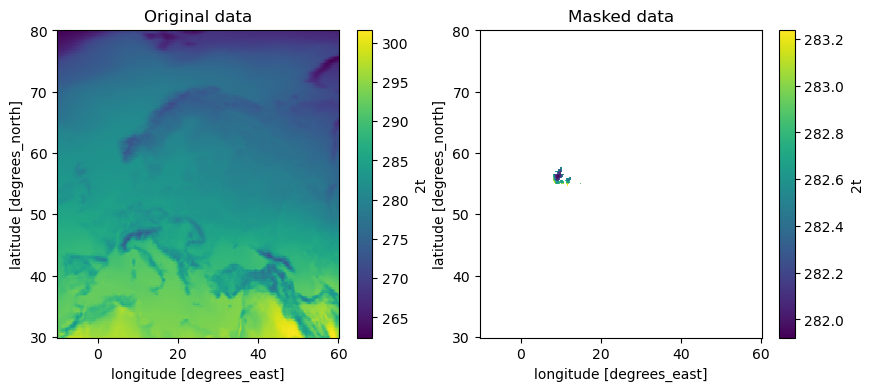

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
era5_data.to_xarray()['2t'].mean(dim='forecast_reference_time').plot(ax=axes[0])
axes[0].set_title('Original data')
# Single masked data
single_masked_data['2t'].mean(dim='forecast_reference_time').isel(index=0).plot(ax=axes[1])
axes[1].set_title('Masked data')

`shapes.masks` applies the features in the geometry object (`nuts_data`) to the data object (`era5_data`).
It returns an xarray object with an additional dimension, and coordinate variable, corresponding to the 
features in the geometry object.
By default this is the index of the input geodataframe, in this example the index is just an integer
count so it takes the default name `index`.

In [4]:
masked_data = ek_aggregate.spatial.mask(era5_data, nuts_data)
masked_data

<xarray.Dataset> Size: 24GB
Dimensions:                  (index: 37, forecast_reference_time: 1460,
                              latitude: 201, longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
  * index                    (index) int64 296B 0 1 2 3 4 5 ... 32 33 34 35 36
Data variables:
    2t                       (index, forecast_reference_time, latitude, longitude) float64 24GB dask.array<chunksize=(1, 1460, 201, 281), meta=np.ndarray>
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

It is possible to specify a column in the geodataframe to use for the new dimension, for example in NUTS the
`FID` (= feature id) which contains the two letter identier code for each feature:

In [5]:
masked_data = ek_aggregate.spatial.mask(era5_data, nuts_data, mask_dim="FID")
masked_data

<xarray.Dataset> Size: 24GB
Dimensions:                  (FID: 37, forecast_reference_time: 1460,
                              latitude: 201, longitude: 281)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * latitude                 (latitude) float64 2kB 80.0 79.75 ... 30.25 30.0
  * longitude                (longitude) float64 2kB -10.0 -9.75 ... 59.75 60.0
  * FID                      (FID) object 296B 'DK' 'RS' 'EE' ... 'CZ' 'DE' 'NO'
Data variables:
    2t                       (FID, forecast_reference_time, latitude, longitude) float64 24GB dask.array<chunksize=(1, 1460, 201, 281), meta=np.ndarray>
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

Here we demonstrate what we have done by plotting the masked objects we have produced

Text(0.5, 1.0, 'Masked Germany Zoom')

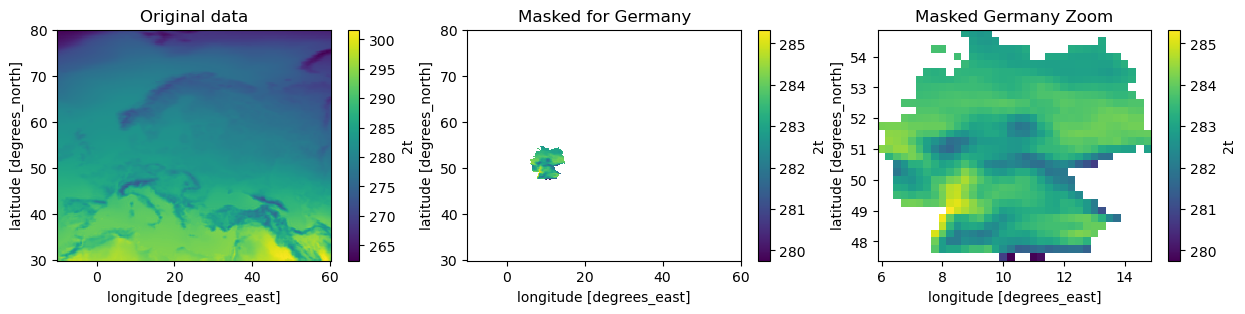

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,3))
era5_data.to_xarray()['2t'].mean(dim='forecast_reference_time').plot(ax=axes[0])
axes[0].set_title('Original data')
masked_data['2t'].sel(FID='DE').mean(dim='forecast_reference_time').plot(ax=axes[1])
axes[1].set_title('Masked for Germany')
germany_data = masked_data.sel(FID='DE').dropna(dim='latitude', how='all').dropna(dim='longitude', how='all')
germany_data['2t'].mean(dim='forecast_reference_time').plot(ax=axes[2])
axes[2].set_title('Masked Germany Zoom')

## Reduce data
### Default behaviour

The default behaviour is to reduce the data along the spatial dimensions, only, and return the reduced data
in the Xarray format it was provided, i.e. `xr.DataArray` or `xr.Dataset`.

The returned object has a new dimension `FID` (feature id) which has a coordinate variable with the values
of the `FID` column in the input `geodataframe`.

The new variable name is made up of the original variable name and the method used to reduce, e.g. `t2m_mean`

In [10]:
reduced_data = ek_aggregate.spatial.reduce(era5_data, nuts_data)
reduced_data

<xarray.Dataset> Size: 444kB
Dimensions:                  (forecast_reference_time: 1460, index: 37)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 12kB 20...
  * index                    (index) int64 296B 0 1 2 3 4 5 ... 32 33 34 35 36
Data variables:
    2t                       (index, forecast_reference_time) float64 432kB 2...
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

### Reduce along additional dimension

For example, any time dimension, this is advisable as it ensures correct handling missing values and weights.

The extra_reduce_dims argument takes a single string or a list of strings corresponding to dimensions to
include in the reduction.

It is also possible to select a column in the geodataframe to use to populate the dimension and coordinate 
variable created by the reduction using the `mask_dim` kwarg, here we choose the `"FID"` column.

In [11]:
reduced_data = ek_aggregate.spatial.reduce(era5_data, nuts_data, mask_dim="FID", extra_reduce_dims='forecast_reference_time', all_touched=True)
reduced_data

<xarray.Dataset> Size: 592B
Dimensions:  (FID: 37)
Coordinates:
  * FID      (FID) object 296B 'DK' 'RS' 'EE' 'EL' 'ES' ... 'CY' 'CZ' 'DE' 'NO'
Data variables:
    2t       (FID) float64 296B 282.6 284.9 280.7 289.0 ... 282.8 283.2 273.9
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

### Weighted reduction

Provide numpy/xarray arrays of weights, or use predefined weights options, i.e. `latitude`:

In [12]:
reduced_data_xr = ek_aggregate.spatial.reduce(era5_data, nuts_data, weights='latitude', mask_dim="FID", extra_reduce_dims='forecast_reference_time', all_touched=True)
reduced_data_xr

<xarray.Dataset> Size: 592B
Dimensions:  (FID: 37)
Coordinates:
  * FID      (FID) object 296B 'DK' 'RS' 'EE' 'EL' 'ES' ... 'CY' 'CZ' 'DE' 'NO'
Data variables:
    2t       (FID) float64 296B 282.6 284.9 280.7 289.1 ... 282.8 283.2 275.4
Attributes: (12/13)
    param:        2t
    paramId:      167
    class:        ea
    stream:       oper
    levtype:      sfc
    type:         an
    ...           ...
    date:         20150101
    time:         0
    domain:       g
    number:       0
    Conventions:  CF-1.8
    institution:  ECMWF

## Return as a pandas dataframe

**WARNING: Returning reduced data in pandas format is considered experimental and may change in futureversions of earthkit-climate** 

It is possible to return the reduced data in a fully expanded geopandas dataframe which contains the geometry 
and aggregated data.
Additional columns for the data values and rows and indexes added to fully describe the reduced data.

The returned object fully supports pandas indexing and in-built convenience methods (e.g. plotting),
but it comes with memory usage cost, hence in this example we reduce along all dimensions.

In [13]:
reduced_data_pd = ek_aggregate.spatial.reduce(era5_data, nuts_data, return_as="pandas", mask_dim="FID", extra_reduce_dims="forecast_reference_time")
reduced_data_pd[:10]

Returning reduced data in pandas format is considered experimental and may change in futureversions of earthkit


,id,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry,2t
FID,,,,,,,,,,,,
DK,DK,DK,0,DK,Danmark,Danmark,0,0,0,DK,"MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...",282.484393
RS,RS,RS,0,RS,Serbia,Srbija/Сpбија,0,0,0,RS,"POLYGON ((21.4792 45.193, 21.3585 44.8216, 22....",285.003457
EE,EE,EE,0,EE,Eesti,Eesti,0,0,0,EE,"MULTIPOLYGON (((27.357 58.7871, 27.6449 57.981...",280.562907
EL,EL,EL,0,EL,Elláda,Ελλάδα,0,0,0,EL,"MULTIPOLYGON (((28.0777 36.1182, 27.8606 35.92...",288.214832
ES,ES,ES,0,ES,España,España,0,0,0,ES,"MULTIPOLYGON (((4.391 39.8617, 4.1907 39.7981,...",287.798295
FI,FI,FI,0,FI,Suomi/Finland,Suomi/Finland,0,0,0,FI,"MULTIPOLYGON (((28.8967 69.0426, 28.4782 68.51...",277.202944
FR,FR,FR,0,FR,France,France,0,0,0,FR,"MULTIPOLYGON (((55.8498 -21.1858, 55.7858 -21....",285.116720
HR,HR,HR,0,HR,Hrvatska,Hrvatska,0,0,0,HR,"MULTIPOLYGON (((17.6515 45.8478, 17.9121 45.79...",285.965025
HU,HU,HU,0,HU,Magyarország,Magyarország,0,0,0,HU,"POLYGON ((22.1211 48.3783, 22.1553 48.4034, 22...",285.277263


# Note that the NUTS regions include French foreign territories, hence the extent of the figure.


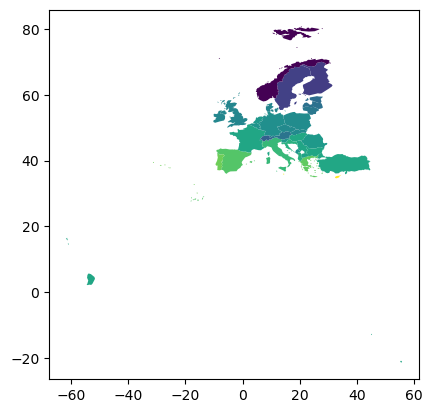

In [18]:
reduced_data_pd.plot("2t")
print('# Note that the NUTS regions include French foreign territories, hence the extent of the figure.')

## Appendix

### Unadvised: return_as = 'pandas' for time-series

This results in very heavy memory usage but may be useful

In [15]:
reduced_data_pd = ek_aggregate.spatial.reduce(era5_data, nuts_data, return_as="pandas", mask_dim="FID")
reduced_data_pd[:5]

Returning reduced data in pandas format is considered experimental and may change in futureversions of earthkit


id NUTS_ID  LEVL_CODE CNTR_CODE NAME_LATN  \
FID forecast_reference_time                                              
DK  2015-01-01 00:00:00      DK      DK          0        DK   Danmark   
    2015-01-01 06:00:00      DK      DK          0        DK   Danmark   
    2015-01-01 12:00:00      DK      DK          0        DK   Danmark   
    2015-01-01 18:00:00      DK      DK          0        DK   Danmark   
    2015-01-02 00:00:00      DK      DK          0        DK   Danmark   

                            NUTS_NAME  MOUNT_TYPE  URBN_TYPE  COAST_TYPE FID  \
FID forecast_reference_time                                                    
DK  2015-01-01 00:00:00       Danmark           0          0           0  DK   
    2015-01-01 06:00:00       Danmark           0          0           0  DK   
    2015-01-01 12:00:00       Danmark           0          0           0  DK   
    2015-01-01 18:00:00       Danmark           0          0           0  DK   
    2015-01-02 00:00:00       Danmark           0          0           0  DK   

                                                                      geometry  \
FID forecast_reference_time                                                      
DK  2015-01-01 00:00:00      MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...   
    2015-01-01 06:00:00      MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...   
    2015-01-01 12:00:00      MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...   
    2015-01-01 18:00:00      MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...   
    2015-01-02 00:00:00      MULTIPOLYGON (((15.1629 55.0937, 15.094 54.996...   

                                     2t  
FID forecast_reference_time              
DK  2015-01-01 00:00:00      278.709224  
    2015-01-01 06:00:00      279.765010  
    2015-01-01 12:00:00      279.772240  
    2015-01-01 18:00:00      279.575683  
    2015-01-02 00:00:00      279.826720

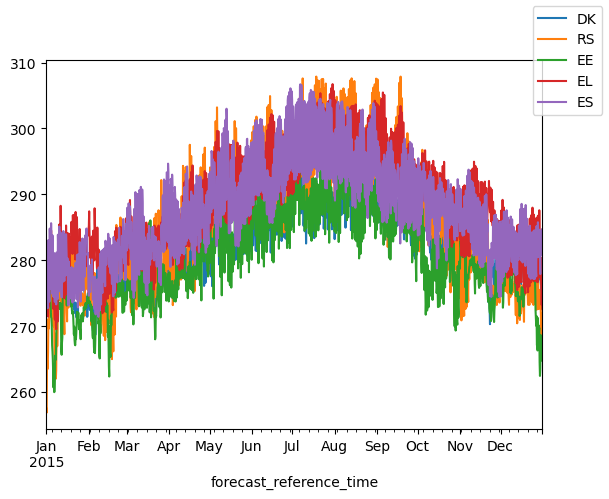

In [16]:
feature_index = "FID"
plot_var = "2t"
# plot_x_vals = reduced_data.attrs[f"{plot_var}_dims"]["time"]
fig, ax = plt.subplots(1)
for feature in reduced_data_pd.index.get_level_values(feature_index).unique()[:5]:
    temp = reduced_data_pd.xs(feature, level=feature_index)
    temp[plot_var].plot(ax=ax, label=feature)
fig.legend()